# Population Coding with Tuned Neurons

## Overview

This page explains one central idea in systems neuroscience: a stimulus is often represented not by one neuron, but by the activity of a population of tuned neurons. Here we focus on orientation, since it is easy to visualize, easy to code, and closely tied to many classic ideas in visual neuroscience.

:::{note} Big Idea: Populations Encode Stimuli

- The visual system contains neurons tuned to different stimulus features.
- A single neuron is not enough to identify the stimulus.
- The useful signal is the pattern of activity across the population.
- Perception depends on which groups of neurons are relatively more active.

:::


Many mammals have visual neurons that are tuned to the orientation of elongated stimuli. These neurons respond when features such as bars, edges, or gratings appear in the visual field. A single neuron, however, is not enough to specify the stimulus. The key idea is that orientation is represented by the pattern of activity across many neurons at once. When there is no strong oriented stimulus, the population remains relatively balanced. But when an oriented stimulus is shown, neurons that prefer that orientation respond more strongly than others, creating an imbalanced population response. In this simple picture, the visual system can infer the stimulus orientation from that pattern across the population.

The next figure makes this idea concrete in two steps: first, the tuning curves of individual cells; second, the population response produced when a single oriented stimulus is shown.
```{figure} ../assets/population_tuning_curves_classical.png
:width: 620px
:align: center

Panel A shows how individual neurons differ from one another: each has its own preferred orientation and tuning curve. Panel B then shows the key idea of population coding: once a single stimulus is presented, the full population produces a structured response pattern.

```

The remainder of this page recreates this figure step by step. First, we build the tuning curves of individual orientation-tuned cells. Then we use those cells together as a population and ask how the full network responds to one stimulus orientation.

---
## The Bell-Shaped Tuning Curve

A tuning curve is a stimulus-response function. Here, we will use the simplest version: a bell-shaped curve, also known as a Gaussian. Using a Gaussian is not the only way to describe an orientation tuning curve, and it may not be the "best" biological model (see Swindale 1998). We use it here because it is simple and easy to code. The shape of a neuron's tuning curve can be characterized by two properties: its center and its spread.

* The center: The neuron responds most strongly to its preferred stimulus, so the center of the Gaussian is placed at the neuron's preferred orientation.
* The spread: A neuron also responds to orientations near its preferred orientation. The spread of the Gaussian tells us how far from the preferred orientation a stimulus can be and still elicit a response.

## Build the Tuning Curve Network

We will create a population of visual neurons. Each neuron will have a Gaussian-shaped tuning curve. Different cells will have different orientation preferences, so the Gaussians will have different centers. All cells will have the same tuning width. Here, we set the spread of all neurons to 15 degrees. This means a neuron responds mostly to orientations within about +/- 15 degrees of its preferred orientation.


In [1]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

# Creating the tuning function
def normal_dist(ori_vals, center, spread):
    Y = np.exp(-0.5 * ((ori_vals - center) / spread) ** 2)
    return Y

# 15 neurons with different orientation preferences
# that evenly span all orientations from 1 to 180 degrees
num_cells = 15
ori_vals = np.arange(0, 180, 10)
ori_pref_list = np.linspace(1, 180, num_cells)

# all curves have a spread/width of 15
tun_curve_width = 15
data = []
for k, n in enumerate(ori_pref_list):
    response = normal_dist(ori_vals, n, tun_curve_width)
    data.append(dict(zip(ori_vals, response)))

df = pd.DataFrame(data)

# display dataframe as a heatmap
df.style.background_gradient(cmap='viridis').set_properties(
    **{'font-size': '5px'}
)


,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170
0,0.997780,0.835270,0.448332,0.154295,0.034047,0.004817,0.000437,0.000025,0.000001,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.655521,0.968654,0.917763,0.557536,0.217168,0.054237,0.008685,0.000892,0.000059,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.208258,0.543215,0.908497,0.974216,0.669834,0.295297,0.083470,0.015128,0.001758,0.000131,0.000006,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.031995,0.147312,0.434889,0.823189,0.999082,0.777469,0.387922,0.124104,0.025457,0.003348,0.000282,0.000015,0.000001,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.002377,0.019318,0.100669,0.336361,0.720605,0.989848,0.871806,0.492325,0.178264,0.041386,0.006161,0.000588,0.000036,0.000001,0.000000,0.000000,0.000000,0.000000
5,0.000085,0.001225,0.011269,0.066462,0.251336,0.609419,0.947451,0.944448,0.603642,0.247378,0.065002,0.010951,0.001183,0.000082,0.000004,0.000000,0.000000,0.000000
6,0.000001,0.000038,0.000610,0.006350,0.042391,0.181437,0.497916,0.876126,0.988457,0.715038,0.331651,0.098631,0.018807,0.002299,0.000180,0.000009,0.000000,0.000000
7,0.000000,0.000001,0.000016,0.000293,0.003457,0.026121,0.126537,0.393022,0.782705,0.999445,0.818276,0.429557,0.144585,0.031204,0.004318,0.000383,0.000022,0.000001
8,0.000000,0.000000,0.000000,0.000007,0.000136,0.001819,0.015550,0.085257,0.299709,0.675539,0.976295,0.904673,0.537505,0.204764,0.050016,0.007833,0.000787,0.000051
9,0.000000,0.000000,0.000000,0.000000,0.000003,0.000061,0.000924,0.008943,0.055496,0.220802,0.563279,0.921349,0.966284,0.649779,0.280161,0.077451,0.013729,0.001560


<!-- ```{figure} ../assets/tuningpop_heatmap.png
:width: 620px
:align: center
``` -->
Above is a population response heatmap. There should be 15 rows, one for each neuron, and 18 columns, one for each stimulus orientation. The color tells us how strongly each neuron responds to each orientation.

Now look at one neuron at a time. A single-cell tuning curve is a horizontal slice through the heat map above. Use the slider in the next figure to choose a different neuron. Watch how the peak of the curve shifts as you move across cells with different preferred orientations.

In [2]:
# plot the horizontal slice with a Plotly slider
single_cell_fig = go.Figure()

for cell_id in range(num_cells):
    single_cell_fig.add_trace(
        go.Scatter(
            x=ori_vals,
            y=df.iloc[cell_id].values,
            mode='lines+markers',
            name=f'Cell {cell_id}',
            visible=(cell_id == 10),
            hovertemplate='Orientation: %{x}<br>Response: %{y:.3f}<extra></extra>',
        )
    )

single_cell_steps = []
for cell_id in range(num_cells):
    single_cell_steps.append(
        dict(
            method='update',
            label=str(cell_id),
            args=[
                {'visible': [i == cell_id for i in range(num_cells)]},
                {'title': f'Neuron {cell_id}: preferred orientation {ori_pref_list[cell_id]:.1f} degrees'},
            ],
        )
    )

single_cell_fig.update_layout(
    title=f'Neuron 10: preferred orientation {ori_pref_list[10]:.1f} degrees',
    xaxis_title='Stimulus Orientation',
    yaxis_title='Neuron Response',
    yaxis=dict(range=[0, 1.05]),
    height=430,
    margin=dict(l=60, r=30, t=70, b=70),
    showlegend=False,
    sliders=[
        dict(
            active=10,
            currentvalue={'prefix': 'Cell ID: '},
            pad={'t': 45},
            steps=single_cell_steps,
        )
    ],
)

single_cell_fig


<!-- ```{figure} ../assets/tuningpop_singlecellcurve9.png
:width: 560px
:align: center

Single-cell tuning curve.
``` -->
The x-axis is stimulus orientation. The y-axis is in arbitrary units, where 1 means the neuron is responding at its maximum. For cell 10, the maximum response occurs when the stimulus is tilted at about 130 degrees, so this cell has an orientation preference near 130 degrees. Other cells peak at other orientations.

Now plot the curves of all the neurons together:


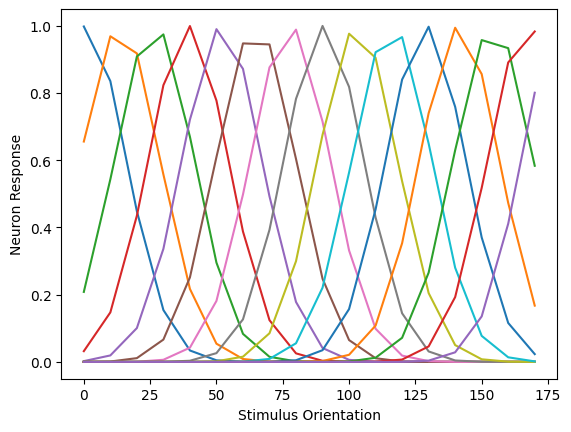

In [3]:
for k, n in enumerate(ori_pref_list):
  df.iloc[k].plot()

plt.xlabel('Stimulus Orientation')
plt.ylabel('Neuron Response');


Each curve describes how one cell responds to different stimulus orientations. The population has orientation preferences that span the full range from 1 to 180 degrees.

## Population Response to One Stimulus

We now move from the single-cell view back to the population view. To see how the full network responds to one stimulus, we take a vertical slice of the heat map. Use the slider in the next figure to change the stimulus orientation and watch which neurons become most active.


In [4]:
# plot the vertical slice with a Plotly slider
population_fig = go.Figure()
cell_ids = list(range(num_cells))
stim_values = list(ori_vals)
active_stim = 90
active_index = stim_values.index(active_stim)

for stim_orientation in stim_values:
    population_fig.add_trace(
        go.Bar(
            x=cell_ids,
            y=df[stim_orientation].values,
            name=f'{stim_orientation} degrees',
            visible=(stim_orientation == active_stim),
            customdata=np.round(ori_pref_list, 1),
            hovertemplate='Cell: %{x}<br>Preferred orientation: %{customdata} degrees<br>Response: %{y:.3f}<extra></extra>',
        )
    )

population_steps = []
for idx, stim_orientation in enumerate(stim_values):
    population_steps.append(
        dict(
            method='update',
            label=str(stim_orientation),
            args=[
                {'visible': [i == idx for i in range(len(stim_values))]},
                {'title': f'Population response to a {stim_orientation}-degree stimulus'},
            ],
        )
    )

population_fig.update_layout(
    title=f'Population response to a {active_stim}-degree stimulus',
    xaxis_title='Neuron ID',
    yaxis_title='Neuronal Response',
    yaxis=dict(range=[0, 1.05]),
    height=430,
    margin=dict(l=60, r=30, t=70, b=70),
    showlegend=False,
    sliders=[
        dict(
            active=active_index,
            currentvalue={'prefix': 'Stimulus: ', 'suffix': ' degrees'},
            pad={'t': 45},
            steps=population_steps,
        )
    ],
)

population_fig


The x-axis is the neuron ID. The y-axis is in arbitrary units, where 1 means the neuron is responding at its maximum.

For a 90-degree stimulus, neurons with orientation preferences near 90 degrees respond most strongly. Neurons that prefer very different orientations are relatively quiet. When you move the stimulus slider, the peak of the population response shifts to a different part of the neural population.

The population response is also bell-shaped. In other words, the response of the whole population has a similar shape to the tuning curve of an individual cell.

## Why This Matters

The logic of orientation-tuned response appears throughout visual neuroscience. Perception often depends on the relative activity of neural populations. That idea helps explain the [motion aftereffect](../chapter_illusions/pg_git_mae.md), where adaptation changes the balance of motion-tuned cells, and the [tilt illusion](../chapter_illusions/pg_git_tilt.md), where surrounding context may shift the activity of orientation-tuned cells.
